In [28]:
power = [3.2160163e-08, 3.1989156e-08, 3.1799388e-08, 3.2648501e-08, 5.1381019e-08, 1.3021011e-07, 2.7572884e-07, 4.6731688e-07, 6.7770873e-07, 8.8909451e-07, 1.0859176e-06, 1.2539039e-06, 1.3829662e-06, 1.4729247e-06, 1.537227e-06, 1.5830792e-06, 1.6145332e-06, 1.636355e-06, 1.6518892e-06, 1.6631693e-06, 1.6713373e-06, 1.6768266e-06, 1.6815342e-06, 1.6850013e-06, 1.6887763e-06, 1.6926111e-06, 1.695388e-06, 1.6961121e-06, 1.6966576e-06, 1.7000191e-06, 1.7041311e-06, 1.7069558e-06, 1.7072995e-06, 1.7069541e-06, 1.7076433e-06, 1.708825e-06, 1.7106399e-06, 1.713736e-06, 1.7171817e-06, 1.7209423e-06, 1.7233059e-06, 1.7233648e-06, 1.7209178e-06, 1.7185439e-06, 1.7174031e-06, 1.7179491e-06, 1.7204301e-06, 1.7234063e-06, 1.7238948e-06, 1.7233135e-06]

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import matplotlib
%matplotlib notebook

In [31]:
xr_data = aom_power_calibration.calibrate_power(aom_channel="Laser_520", get_meas_data=True)

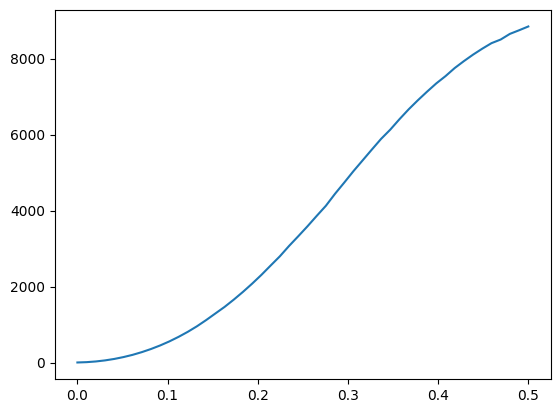

In [32]:
xr_plot_data = xr_data.copy()

display(plt.plot(np.array(xr_plot_data.voltage.values), np.array(xr_plot_data.power.values)*1e6))


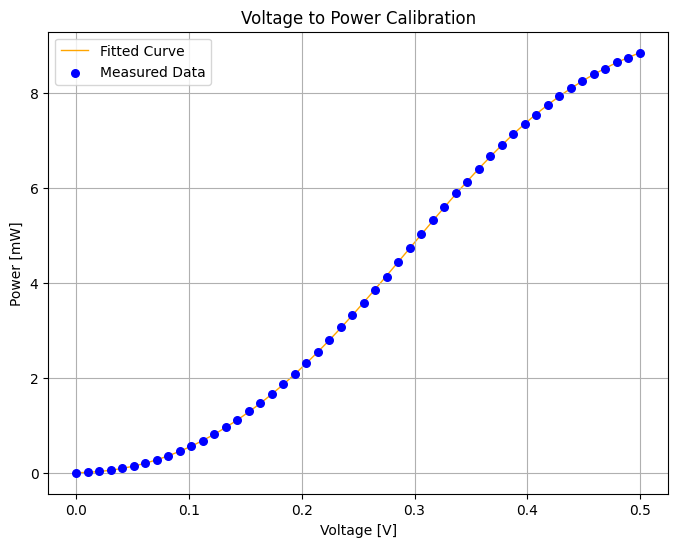

In [33]:
fit_func = AOMPowerFit(
    np.array(xr_plot_data.voltage.values), 
    np.array(xr_plot_data.power.values))

fit_func.fit_data()
fit_func.plot_fit()


In [ ]:
from lmfit import Model
class AOMPowerFit:
    """
    Class to handle AOM power fitting using the refined model with lmfit.
    """

    def __init__(self, V_data, P_data, model=None, init_guess_func=None):
        """
        Initialize with voltage and power data.
        """
        self.V_data = np.array(V_data)
        self.P_data = np.array(P_data)
        self.init_guess_func = init_guess_func

        if not model:
            self.model = Model(self.aom_power)  # Initialize the model
            self.init_guess_func = self.aom_power_init_guess_func

    @staticmethod
    def aom_power(V, P_max, V_s, n_num, n_den, alpha, offset, v0, init_guess_func=None):
        """
        Asymmetric Hill-type saturation.
        n_num: exponent on numerator (controls onset steepness)
        n_den: exponent inside denominator (controls tail approach)
        """
        x = np.maximum(V - v0, 0.0)
        return offset + P_max * (x**n_num) / ((x**n_den + V_s**n_den)**alpha)

    @staticmethod
    def aom_power_init_guess_func(V, P):
        """
        Initial guess dict for asymmetric AOM power model.
        """
        V, P = np.asarray(V, float), np.asarray(P, float)
        ymin, ymax = P.min(), P.max()
        Pmax0 = ymax - ymin
        offset0 = ymin

        # threshold (≈2% above baseline)
        thr = offset0 + 0.02 * Pmax0
        idx_thr = np.argmax(P >= thr) if np.any(P >= thr) else 0
        v0_0 = V[idx_thr]

        # half-max point
        half = offset0 + 0.5 * Pmax0
        i_half = np.argmin(np.abs(P - half))
        Vs0 = max(1e-9, V[i_half] - v0_0)

        # slope heuristic for n
        j0, j1 = max(0, i_half-1), min(len(V)-1, i_half+1)
        slope = (P[j1]-P[j0]) / max(1e-12, V[j1]-V[j0])
        n0 = float(np.clip(4*slope*Vs0/max(Pmax0,1e-12), 0.5, 6.0))

        return {
            "P_max": Pmax0,
            "V_s": Vs0,
            "n_num": n0,
            "n_den": n0,
            "alpha": 1.0,
            "offset": {"value": offset0, "min": 0, "max": np.inf},
            "v0": v0_0,
        }

    def get_initial_guesses(self):
        """
        Generate initial guesses dynamically based on the input data.
        """
        return self.init_guess_func(self.V_data, self.P_data)

    def fit_data(self):
        """
        Fit the AOM power model to the data using lmfit.
        """
        if self.init_guess_func:
            params = self.model.make_params(**self.get_initial_guesses())
        else:
            params = self.model.make_params()

        # Perform the fit
        self.result = self.model.fit(self.P_data, params, V=self.V_data)
        return self.result

    def plot_fit(self):
        """
        Plot the measured data and the fitted curve.
        """
        if not hasattr(self, "result"):
            raise ValueError("Fit the data first using `fit_data()`.")

        # Generate the fitted curve
        V_fit = np.linspace(min(self.V_data), max(self.V_data), 500)
        P_fit = self.model.func(V_fit, **self.result.best_values)

        # Plot
        plt.figure(figsize=(8, 6))
        plt.plot(V_fit, P_fit*1e3, label="Fitted Curve", color="orange", linewidth=1, zorder=1)
        plt.scatter(self.V_data, self.P_data*1e3, label="Measured Data", color="blue", s=30, zorder=3)
        plt.xlabel("Voltage [V]")
        plt.ylabel("Power [mW]")
        plt.title("Voltage to Power Calibration")
        plt.legend()
        plt.grid()
        plt.show()

    def print_fit_report(self):
        """
        Print the fit report.
        """
        if not hasattr(self, "result"):
            raise ValueError("Fit the data first using `fit_data()`.")
        print(self.result.fit_report())


In [49]:
test.power.plot()

In [61]:
%matplotlib widget 

In [7]:
# 1) Use the inline backend (shows plots in the notebook)
%matplotlib inline

# 2) Import
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

# 3) Quick sanity check: which backend?
print(matplotlib.get_backend())  # expect: module://matplotlib_inline.backend_inline


module://matplotlib_inline.backend_inline


In [51]:
from IPython.display import display